<a href="https://colab.research.google.com/github/bigdatahub-ap/indonesia-workshop-on-use-of-ads/blob/main/notebooks/Index_Calculation_Exercises_Solutions_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multilateral Index Calculation in R - Exercises

In order to do the exercises we need to load the packages and prepare the dataset first.


In [ ]:
# Install required packages
install.packages(c('PriceIndices', 'IndexNumR'), repos='https://cran.r-project.org')

# Set the options such that unnessecary warnings are muted
#knitr::opts_chunk$set(echo = TRUE)
#options(tidyverse.quiet = TRUE)


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘plyr’, ‘stringdist’, ‘lpSolve’, ‘checkmate’, ‘reshape’, ‘reclin2’, ‘strex’, ‘lazyeval’, ‘crosstalk’




It is possible to do the exercises using the following packages. However, you can load and use other packages if you want.

In [ ]:
library(PriceIndices) # for price index calculations
library(IndexNumR)    # for price index calculations
library(tidyverse)    # for data analysis
library(ggplot2)      # for graphics



Attaching package: ‘IndexNumR’


The following object is masked from ‘package:PriceIndices’:

    elasticity


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Dataset

We use the same data as yesterday from the set of food prices in Italian supermarkets provided by Banca d'Italia, Università Campus Bio-Medico and Università degli Studi della Tuscia. The complete dataset is available [here](https://zenodo.org/records/14927602). We aggregated the data by month and added artificial quantities.



In [ ]:
data <- read.csv("https://raw.githubusercontent.com/UN-Task-Team-for-Scanner-Data/alternative-data-sources-price-statistics/refs/heads/main/data/monthly_avg_price_with_qty.csv")

# Filter for bananas in Store 3
data <- data %>% filter(COICOP5 %in% "Salad" & store_id %in% 3) %>%
         mutate(product_id = as.numeric(factor(product)),
                volume = price * quantity,
                total_quantity = NULL, quantity_share = NULL)

# Extract package size from product description and convert to kg
data <- data %>% mutate(size = case_when(
  str_sub(product, -2, -1) == "kg" ~ as.numeric(str_extract(product, "(\\d+).(\\d+)")),
  str_sub(product, -2, -1) == "gr" ~ as.numeric(str_extract(product, "(\\d+).(\\d+)")) / 1000,
  str_sub(product, -2, -1) == "pz" ~ as.numeric(str_extract(product, "(\\d+).(\\d+)")) * .18))

# Adjust price to "per kg" and quantity to "kg sold"
data <- data %>% mutate(price = price / size, quantity = quantity * size)


# Index calculation

The exercise can be done using either the `IndexNumR` or `PriceIndices` package. Choose the one you prefer.

**Exercise 1**       
Format the dataset such that it works as input for one of the packages and name the data.frame `input`.




In [ ]:

# Input for PriceIndices functions
input_pi <- data_preparing(data,
               time       = "month_year", # convert the period into date format and rename the column and
               prices     = "price",
               quantities = "quantity",
               prodID     = "product_id")
cat("An input data.frame for PriceIndices:\n\n")
head(input_pi)

# Input for IndexNumR functions
input_in <- data %>% mutate(pervar = monthIndex(ym(data$month_year)))
cat("\n\nAn input data.frame for IndexNumR:\n\n")
head(input_in)

# A data.frame that includes all columns
input <- cbind(input_in, input_pi)

An input data.frame for PriceIndices:



,time,prices,quantities,prodID
,<date>,<dbl>,<dbl>,<chr>
1,2022-12-01,7.265010,31.13706,1
2,2020-12-01,8.062500,19.39783,2
3,2021-01-01,8.304435,19.45712,2
4,2021-02-01,8.062500,19.29304,2
5,2021-03-01,8.062500,21.15349,2
6,2021-04-01,8.062500,16.70443,2




An input data.frame for IndexNumR:



,month_year,product,store_id,COICOP5,COICOP4,price,quantity,product_id,volume,size,pervar
,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2022-12,bonduelle carta delle insalate ricetta croccante 230.0 gr,3,Salad,Vegetable,7.265010,31.13706,1,226.2110,0.23,25
2,2020-12,cuore lattuga 160.0 gr,3,Salad,Vegetable,8.062500,19.39783,2,156.3950,0.16,1
3,2021-01,cuore lattuga 160.0 gr,3,Salad,Vegetable,8.304435,19.45712,2,161.5804,0.16,2
4,2021-02,cuore lattuga 160.0 gr,3,Salad,Vegetable,8.062500,19.29304,2,155.5501,0.16,3
5,2021-03,cuore lattuga 160.0 gr,3,Salad,Vegetable,8.062500,21.15349,2,170.5500,0.16,4
6,2021-04,cuore lattuga 160.0 gr,3,Salad,Vegetable,8.062500,16.70443,2,134.6795,0.16,5


**Exercise 2**     
Calculate a GEKS-Index using the Fisher formula from December 2020 to December 2022 without splicing.     
*Hint: The GEKS-Fisher method is called "geks" in the PriceIndices package*

In [ ]:
# GEKS-Fisher with PriceIndices::price_indice
geks_pi <- price_indices(input,
                         start="2020-12",
                         end="2022-12",
                         formula="geks",
                         window= 25,
                         interval=TRUE
)

# GEKS-Fisher with IndexNumR::GEKSIndex
geks_in <- GEKSIndex(input %>% filter(pervar <= 25),
                     pvar = "price",
                     qvar = "quantity",
                     pervar = "pervar",
                     prodID = "product_id",
                     indexMethod = "fisher",
                     window = 25,
)

# Both packages in one data.frame
data.frame(month = geks_pi$time,
           indexNumR = geks_in,
           PriceIndices = geks_pi$geks)

month,indexNumR,PriceIndices
<chr>,<dbl>,<dbl>
2020-12,1.000000,1.000000
2021-01,1.116764,1.116764
2021-02,1.106457,1.106457
2021-03,1.043450,1.043450
2021-04,1.063910,1.063910
2021-05,1.137317,1.137317
2021-06,1.124290,1.124290
2021-07,1.123579,1.123579
2021-08,1.124631,1.124631


**Exercise 3**       
Now calculate spliced GEKS-Fisher indices. Use a window splice with a window length of 13 months as well as a movement splice with a window length of 4 months. Compare all three indices.



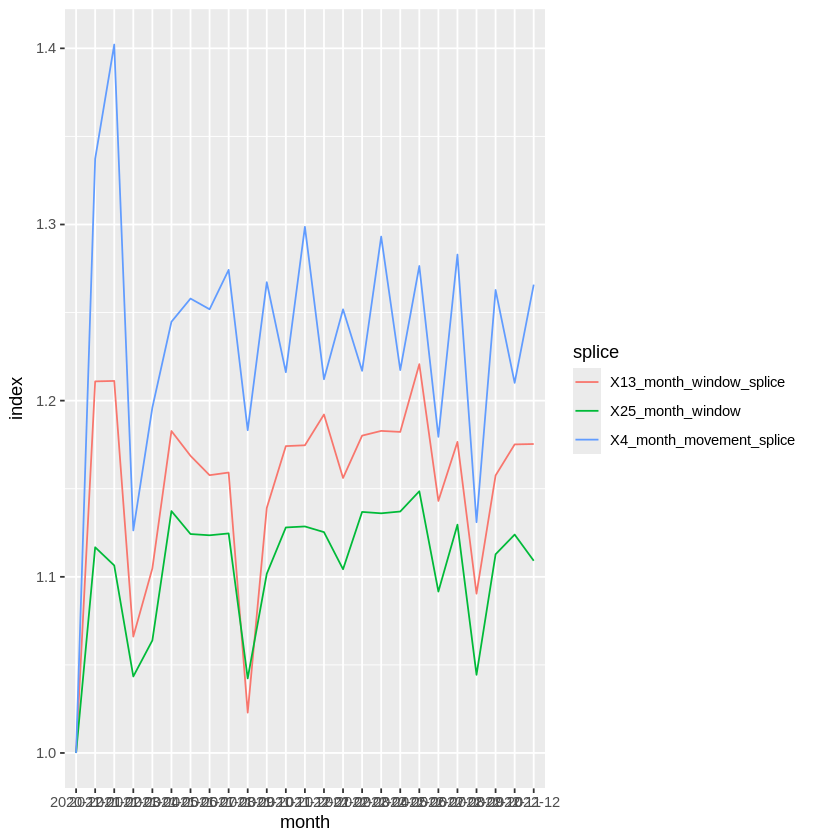

In [ ]:
# Window splice with PriceIndices::price_indice
geks_window_pi <- price_indices(input,
                             start = "2020-12",
                             end = "2022-12",
                             formula = "geks_splice",
                             window = 13,
                             interval =T,
                             splice = "window"
)

# Window splice with IndexNumR::GEKSIndex
geks_window_in <- GEKSIndex(input %>% filter(pervar <= 25),
                            pvar = "price",
                            qvar = "quantity",
                            pervar = "pervar",
                            prodID = "product_id",
                            indexMethod = "fisher",
                            sample = "matched",
                            window = 13,
                            splice = "window"
)

# Movement splice with PriceIndices::price_indice
geks_movement_pi <- price_indices(input,
                               start="2020-12",
                               end="2022-12",
                               formula="geks_splice",
                               window= 4,
                               interval=TRUE,
                               splice = "movement"
)

# Movement splice with IndexNumR::GEKSIndex
geks_movement_in <- GEKSIndex(input %>% filter(pervar <= 25),
            pvar = "price",
            qvar = "quantity",
            pervar = "pervar",
            prodID = "product_id",
            indexMethod = "fisher",
            sample = "matched",
            window = 4,
            splice = "hasp", # "window", "movement", "half", "mean", "fbew", "fbmw", "wisp", "hasp" or mean_pub" are the options
            imputePrices = NULL
)


# The results in one data.frame
comparison <- data.frame(month = geks_pi$time,
                      "25_month_window" = geks_pi$geks,
                      "13_month_window_splice" = geks_window_pi$geks_splice,
                      "4_month_movement_splice" = geks_movement_in
                      )

# Visualising the results
pivot_longer(comparison, cols = -1, names_to = "splice", values_to = "index") %>%
  ggplot(., aes(x = month, y = index, group = splice, color = splice)) + geom_line()

**Exercise 4**      
Calculate an index using the weighted time product dummy or the Geary-Khamis method. From December 2020 to December 2022 and compare it to the geks index.

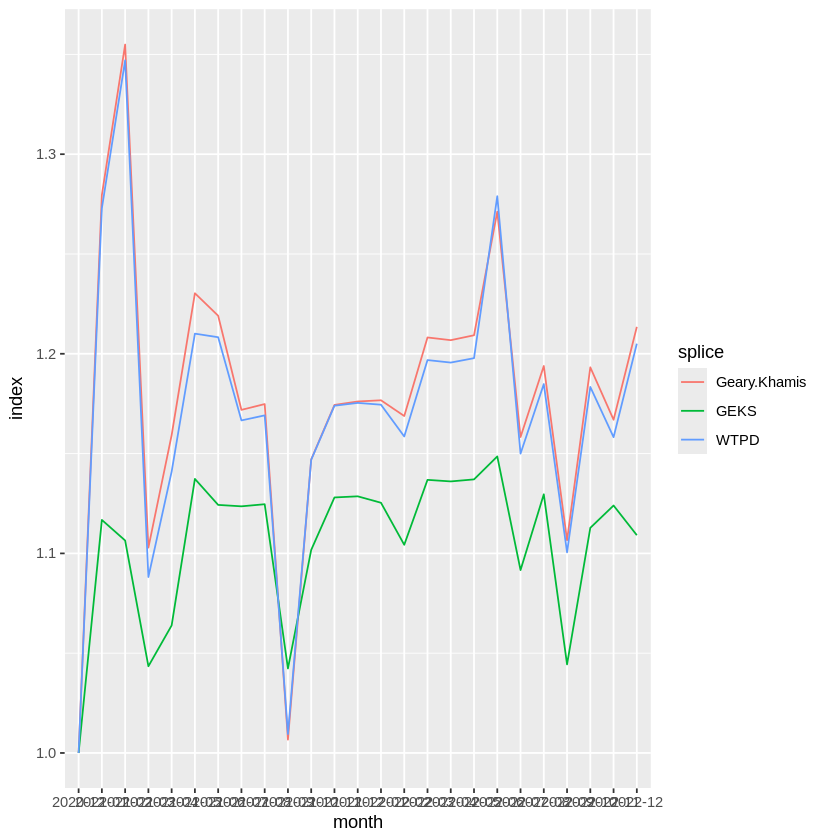

In [ ]:
# WTPD with PriceIndices::price_indice
wtpd_pi <- price_indices(input, start="2020-12", end="2022-12",
  formula="tpd", window=25, interval=TRUE)

# WTPD with IndexNumR::WPTDIndex
wtpd_in <- WTPDIndex(input %>% filter(pervar <= 25),
                     pvar = "price",
                     qvar = "quantity",
                     pervar = "pervar",
                     prodID = "product_id",
                     window = 25
          )

# Geary-Khamis with PriceIndices::price_indice
gk_pi <- price_indices(input, start="2020-12", end="2022-12",
  formula="gk", window=25, interval=TRUE)

# Geary-Khamis with IndexNumR::WPTDIndex
gk_in <- GKIndex(input %>% filter(pervar <= 25),
                     pvar = "price",
                     qvar = "quantity",
                     pervar = "pervar",
                     prodID = "product_id",
                     window = 25
          )

# The results in one data.frame
comparison <- data.frame(month = geks_pi$time,
                      "GEKS" = geks_pi$geks,
                      "WTPD" = wtpd_in,
                      "Geary-Khamis" = gk_pi$gk
                      )

# Visualising the results
pivot_longer(comparison, cols = -1, names_to = "splice", values_to = "index") %>%
  ggplot(., aes(x = month, y = index, group = splice, color = splice)) + geom_line()

**Bonus**
Calculate a GEKS-Jevons index and compare it to a chain linked bilateral Jevons index.

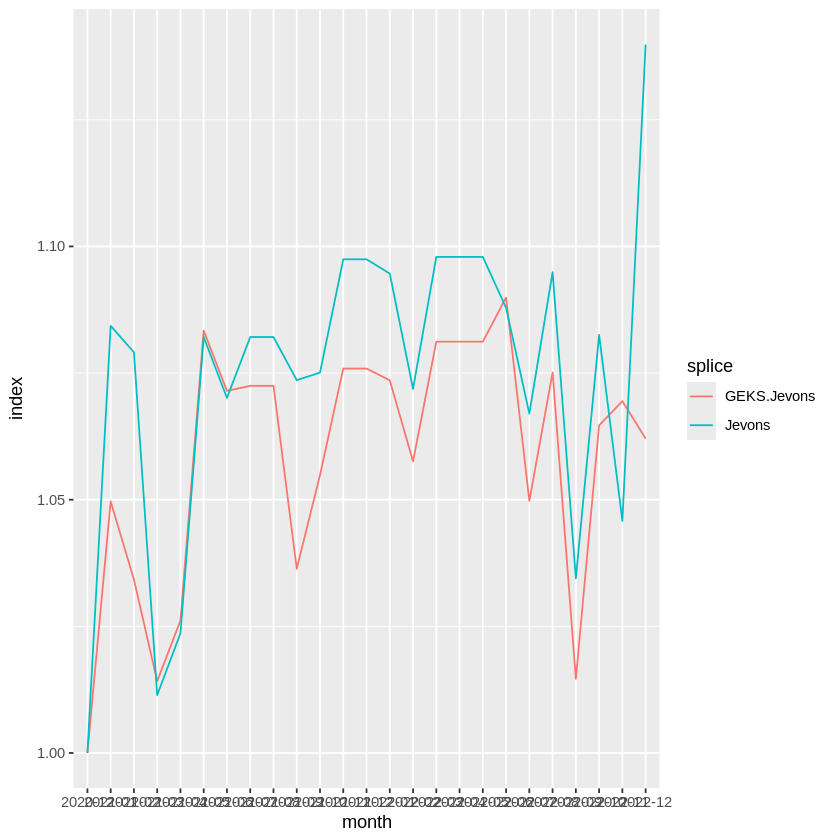

In [ ]:
# WTPD with PriceIndices::price_indice
jevons_pi <- price_indices(input, start="2020-12", end="2022-12",
  formula="chjevons", interval=TRUE)

# WTPD with IndexNumR::WPTDIndex
jevons_in <- priceIndex(input %>% filter(pervar <= 25),
                     pvar = "price",
                     qvar = "quantity",
                     pervar = "pervar",
                     prodID = "product_id",
                     indexMethod = "jevons",
                     output = "chained"
          )

# GEKS-Jevons with PriceIndices::price_indice
geks_jevons_pi <- price_indices(input, start="2020-12", end="2022-12",
  formula="geksj", window=25, interval=TRUE)

# GEKS-Jevons with IndexNumR::WPTDIndex
geks_jevons_in <- GEKSIndex(input %>% filter(pervar <= 25),
                     pvar = "price",
                     qvar = "quantity",
                     pervar = "pervar",
                     prodID = "product_id",
                     indexMethod = "jevons",
          )

# The results in one data.frame
comparison <- data.frame(month = jevons_pi$time,
                      "GEKS-Jevons" = geks_jevons_pi$geksj,
                      "Jevons" = jevons_in
                      )

# Visualising the results
pivot_longer(comparison, cols = -1, names_to = "splice", values_to = "index") %>%
  ggplot(., aes(x = month, y = index, group = splice, color = splice)) + geom_line()
